# predict amphitheater or outside amphitheater + position based on gps data

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df = pd.read_csv('df_no_rendandancy.csv')
df.head()


,Amphi,Position,Latitude,Longitude,Accuracy_m,Altitude_m
0,1,1,36.688383,2.866642,43.7,177.1
1,1,1,36.688379,2.866643,42.4,181.4
2,1,1,36.688377,2.866684,13.6,181.4
3,1,1,36.688370,2.866685,11.2,181.3
4,1,1,36.688366,2.866684,9.1,181.4


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1424 entries, 0 to 1423
Data columns (total 6 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   Amphi       1424 non-null   int64  
 1   Position    1424 non-null   int64  
 2   Latitude    1424 non-null   float64
 3   Longitude   1424 non-null   float64
 4   Accuracy_m  1424 non-null   float64
 5   Altitude_m  1424 non-null   float64
dtypes: float64(4), int64(2)
memory usage: 66.9 KB


data contains:
- amphi: first target variable, 8 amphitheaters
- position: second target variable, represents the position inside the amphitheater, 3 classes(front, middle, back)
- gps data: 3 descriptive features, Latitude ,Longitude and Altitude coordinates
- accuracy: since the data is indoor, the gps data is not accurate, so we have accuracy column that represents the accuracy of the gps data, the lower the accuracy the better the gps data

amphitheaters are in two floors, 4 amphies by floor, this floors are spreaded as line not cycle, in addition amphi 5 is above amphi 1, amphi 6 is above amphi 2 and so on, so we will check if there is any difference between the two floors or not, and if there is any difference between the amphies in the same floor or not.
for position we have 3 poistions, this positions are spreaded in line not cycle, so we will check if there is any difference between the positions or not.

## data exploration

In [4]:
df.describe()

,Amphi,Position,Latitude,Longitude,Accuracy_m,Altitude_m
count,1424.000000,1424.000000,1424.000000,1424.000000,1424.000000,1424.000000
mean,4.760534,2.054073,36.688306,2.866335,19.715660,179.274438
std,2.377179,0.826832,0.000170,0.000260,37.992136,2.307522
min,1.000000,1.000000,36.686408,2.864223,3.000000,174.900000
25%,3.000000,1.000000,36.688302,2.866154,6.500000,176.800000
50%,5.000000,2.000000,36.688331,2.866220,8.300000,181.100000
75%,7.000000,3.000000,36.688343,2.866495,14.000000,181.300000
max,8.000000,3.000000,36.688515,2.866875,400.000000,182.800000


cooredinates are close to each other since the data is indoor and in one place
accuracy goes usually from 0 to 15 merters, however max accuracy is 400 meter indicate that there is some noise in the data, we will handle this later

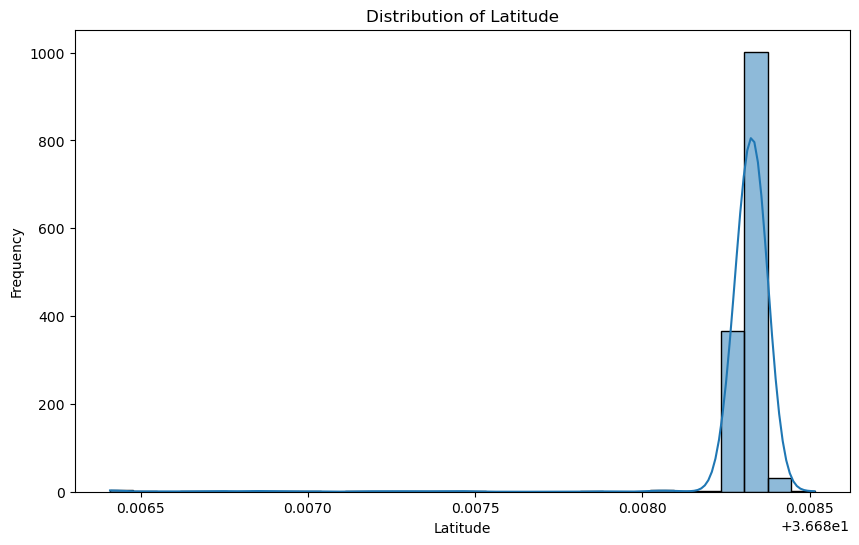

In [5]:
# visulize description of the data
plt.figure(figsize=(10, 6))
sns.histplot(df['Latitude'], bins=30, kde=True)
plt.title('Distribution of Latitude')
plt.xlabel('Latitude')
plt.ylabel('Frequency')
plt.show()

latitude histogram show that most of the data is concentrated in a small range of latitude,this is becaue amphitheaters are parallel to each other and close to each other.

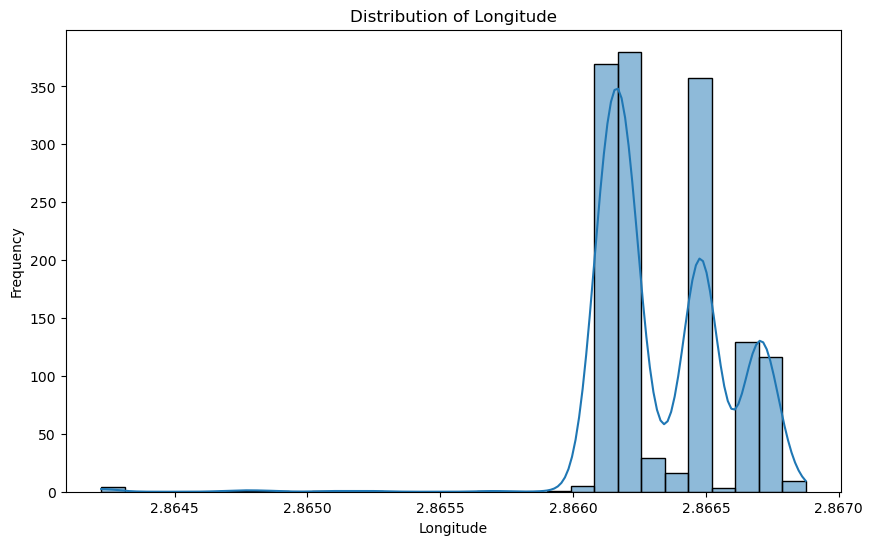

In [6]:
plt.figure(figsize=(10, 6))
sns.histplot(df['Longitude'], bins=30, kde=True)
plt.title('Distribution of Longitude')
plt.xlabel('Longitude')
plt.ylabel('Frequency')
plt.show()

Longitude histogram show more variance compared to Latitude this is becaude amphitheaters are spread in longitude direction more than latitude direction(theh are in line in longitude direction)

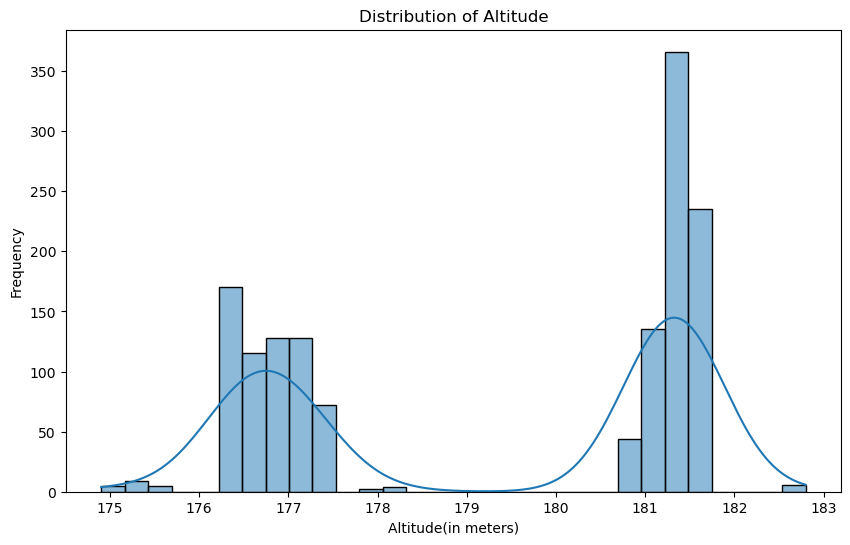

In [7]:
plt.figure(figsize=(10, 6))
sns.histplot(df['Altitude_m'], bins=30, kde=True)
plt.title('Distribution of Altitude')
plt.xlabel('Altitude(in meters)')
plt.ylabel('Frequency')
plt.show()

altitude is distributed in two main ranges [175-178] and [180-183], this is expected since amphitheaters are distributed in two main floors, the first floor is the main floor and the second floor is the upper floor, however there are some data points that are in the range of [178-180] which is not expected, we will handle this later
in one floor altitude has some variance because amphitheater is not flat and there are some stairs, so the altitude can vary even in the same floor, this may help us to predict the position inside the amphitheater

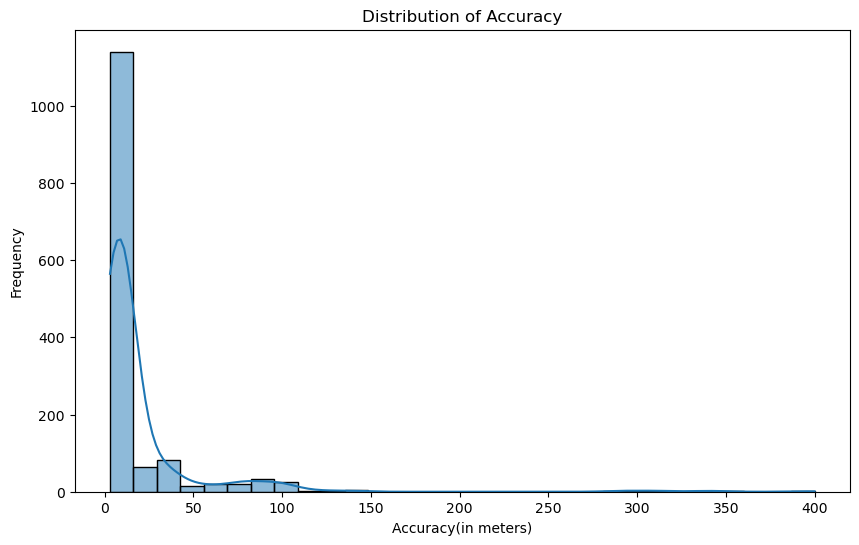

In [8]:
plt.figure(figsize=(10, 6))
sns.histplot(df['Accuracy_m'], bins=30, kde=True)
plt.title('Distribution of Accuracy')
plt.xlabel('Accuracy(in meters)')
plt.ylabel('Frequency')
plt.show()

we note that accuracy is right skewed, most of the data has accuracy less than 15 meters, however there are some data points that have accuracy more than 100 meters, this is not expected since the data is indoor

to confirm previous observation, we will check scatter plot of latitude and longitude, we will see that the data is concentrated in a small area

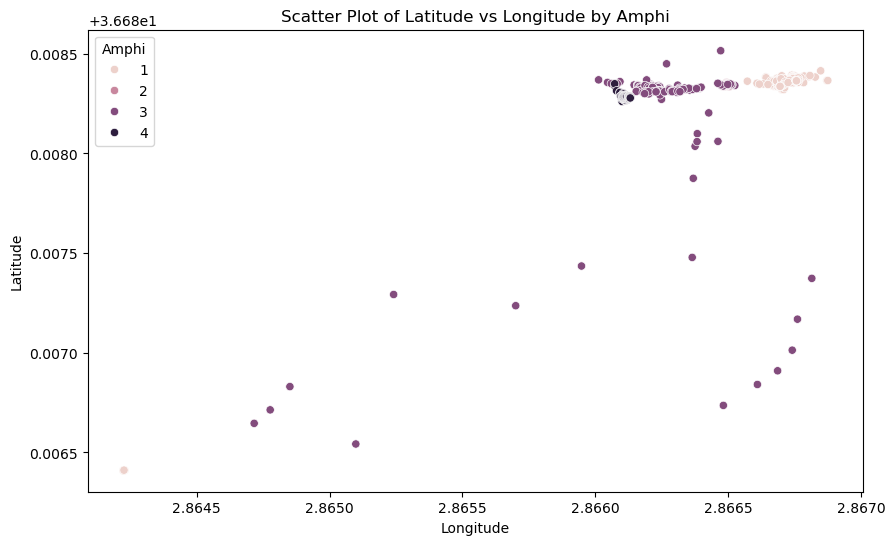

In [9]:
# since amphies are in two floors, we will check only four first amphies, to see if there is any difference between them
df_plot = df[df['Amphi'] < 5]
plt.figure(figsize=(10, 6))
sns.scatterplot(x='Longitude', y='Latitude', hue='Amphi', data=df_plot)
plt.title('Scatter Plot of Latitude vs Longitude by Amphi')
plt.xlabel('Longitude')
plt.ylabel('Latitude')
plt.legend(title='Amphi')
plt.show()

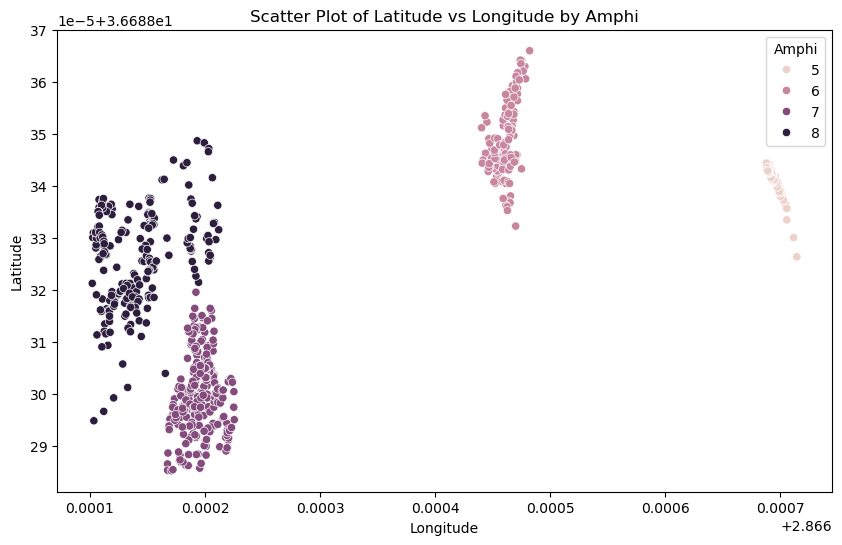

In [10]:
# since amphies are in two floors, we will check only four first amphies, to see if there is any difference between them
df_plot = df[df['Amphi'] >= 5]
plt.figure(figsize=(10, 6))
sns.scatterplot(x='Longitude', y='Latitude', hue='Amphi', data=df_plot)
plt.title('Scatter Plot of Latitude vs Longitude by Amphi')
plt.xlabel('Longitude')
plt.ylabel('Latitude')
plt.legend(title='Amphi')
plt.show()

The scatter plot shows that amphitheaters on floor 1 (amphi 1-4) are relatively well separated in the longitude direction, with each amphi occupying a distinct range. Latitude values overlap significantly between amphitheaters, making it difficult to distinguish between them based on latitude alone. This confirms that longitude is a more useful feature than latitude for differentiating between floor 1 amphitheaters.

points of floor 1 are concentrated unlike floor 2, in addtion that amphi 3 ishave many points are away from amphies, this likely due poor accuracy indoor gps data

In [11]:
# IQR of accuracy
Q1 = df['Accuracy_m'].quantile(0.25)
Q3 = df['Accuracy_m'].quantile(0.75)
IQR = Q3 - Q1
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR
print(f'Lower Bound: {lower_bound}, Upper Bound: {upper_bound}')


Lower Bound: -4.75, Upper Bound: 25.25


the IQR method gives us an upper bound of 25.25 meters, since the lower bound is negative it means there are no low outliers which is expected, we will use 25 meters as threshold to filter out high accuracy points

In [12]:
#check values with high accuracy which aamphi belong and which position they have
high_accuracy = df[df['Accuracy_m'] > 27]
print("number of high accuracy values: ", len(high_accuracy))
df_high_accuracy = high_accuracy.groupby(['Amphi', 'Position']).size().reset_index(name='Count')
print(df_high_accuracy)


number of high accuracy values:  231
   Amphi  Position  Count
0      1         1      3
1      1         2     39
2      1         3     58
3      3         1      9
4      3         2     27
5      3         3     54
6      4         1      1
7      8         1     10
8      8         2      4
9      8         3     26


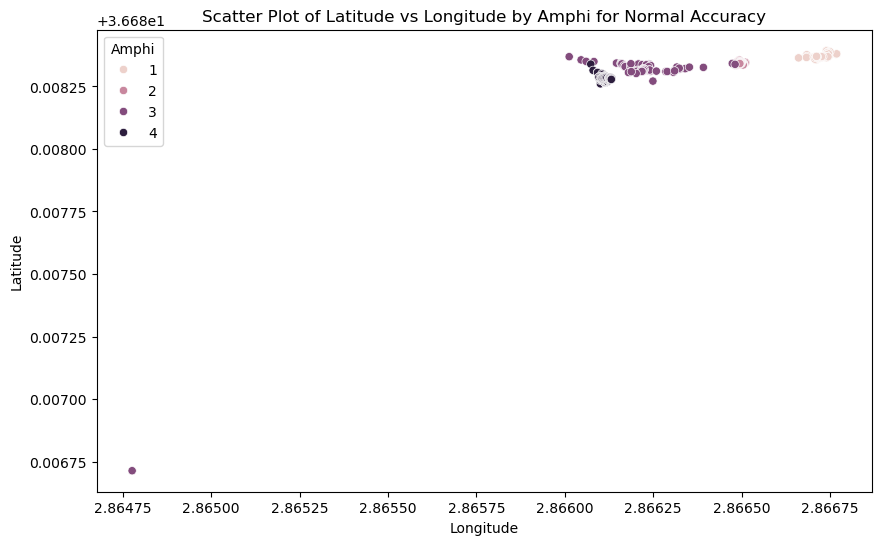

In [13]:
normal_accuracy = df[df['Accuracy_m'] <= 25]
normal_accuracy_1 = normal_accuracy[normal_accuracy['Amphi'] <= 4]
plt.figure(figsize=(10, 6))
sns.scatterplot(x='Longitude', y='Latitude', hue='Amphi', data=normal_accuracy_1)
plt.title('Scatter Plot of Latitude vs Longitude by Amphi for Normal Accuracy')
plt.xlabel('Longitude')
plt.ylabel('Latitude')
plt.legend(title='Amphi')
plt.show()

After filtering out high accuracy points (>25m), the scatter plot for floor 1 shows tighter clustering of data points. The amphitheaters remain relatively well separated in the longitude direction, but the overall spread of points is reduced. This indicates that removing noisy GPS data improves the clarity of the separation between amphitheaters.

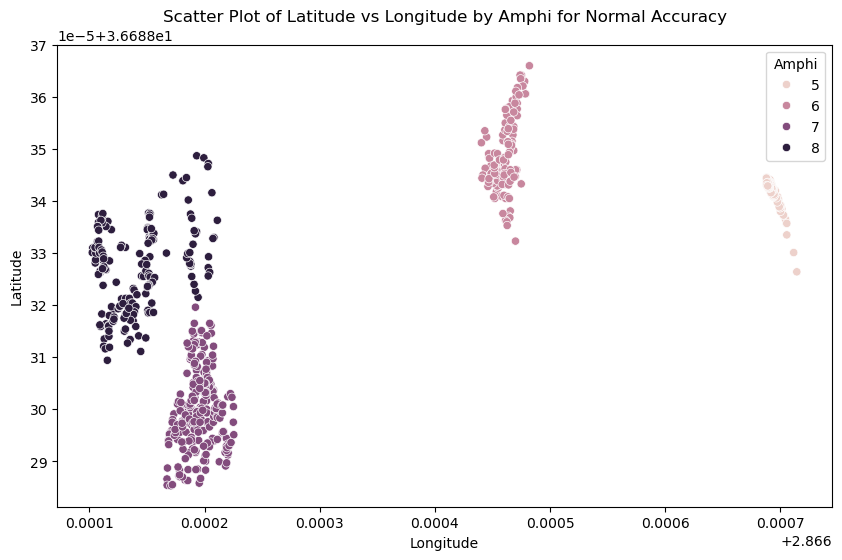

In [14]:
normal_accuracy_2 = normal_accuracy[normal_accuracy['Amphi'] > 4]
plt.figure(figsize=(10, 6))
sns.scatterplot(x='Longitude', y='Latitude', hue='Amphi', data=normal_accuracy_2)
plt.title('Scatter Plot of Latitude vs Longitude by Amphi for Normal Accuracy')
plt.xlabel('Longitude')
plt.ylabel('Latitude')
plt.legend(title='Amphi')
plt.show()

For floor 2 (amphi 5-8), the scatter plot after removing high accuracy points shows that the amphitheaters are more clearly separated compared to floor 1. 

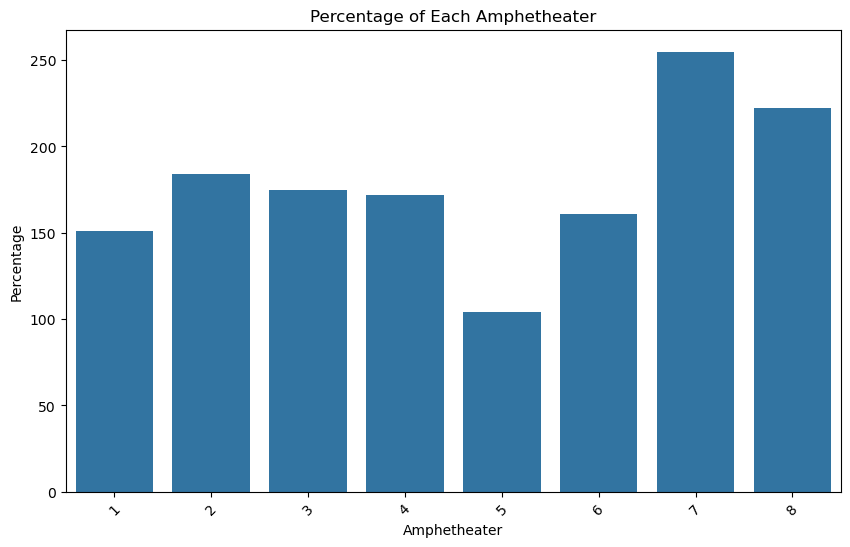

In [15]:
# check percentage of each amphetheater
df_amphetheater = df['Amphi'].value_counts()
plt.figure(figsize=(10, 6))
sns.barplot(x=df_amphetheater.index, y=df_amphetheater.values)
plt.title('Percentage of Each Amphetheater')
plt.xlabel('Amphetheater')
plt.ylabel('Percentage')
plt.xticks(rotation=45)
plt.show()

we note that classes are not equammy ditstributed, amphi 5 has few data points, we may consider stratified sampling to handle this issue

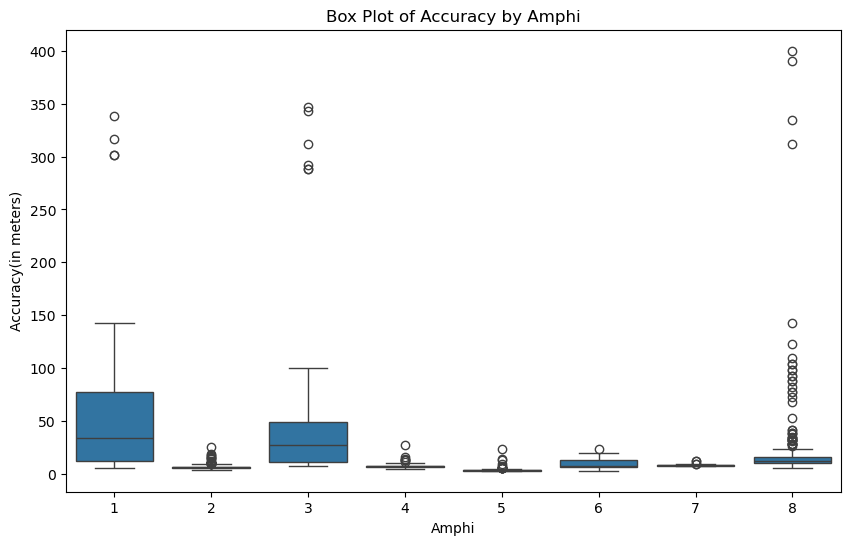

In [16]:
# ananlyze the distribution of accuracy for each amphetheater
plt.figure(figsize=(10, 6))
sns.boxplot(x='Amphi', y='Accuracy_m', data=df)
plt.title('Box Plot of Accuracy by Amphi')
plt.xlabel('Amphi')
plt.ylabel('Accuracy(in meters)')
plt.show()


The boxplot shows the distribution of GPS accuracy for each amphitheater. Amphitheaters 1, 3, and 8 have notably higher accuracy values (worse GPS signal) with larger interquartile ranges and more extreme outliers reaching up to 300-400 meters. In contrast, amphitheaters 2, 4, 5, 6, and 7 have very tight boxes near zero, indicating consistently reliable GPS signal. This variation in GPS accuracy could significantly impact model performance across different amphitheaters.

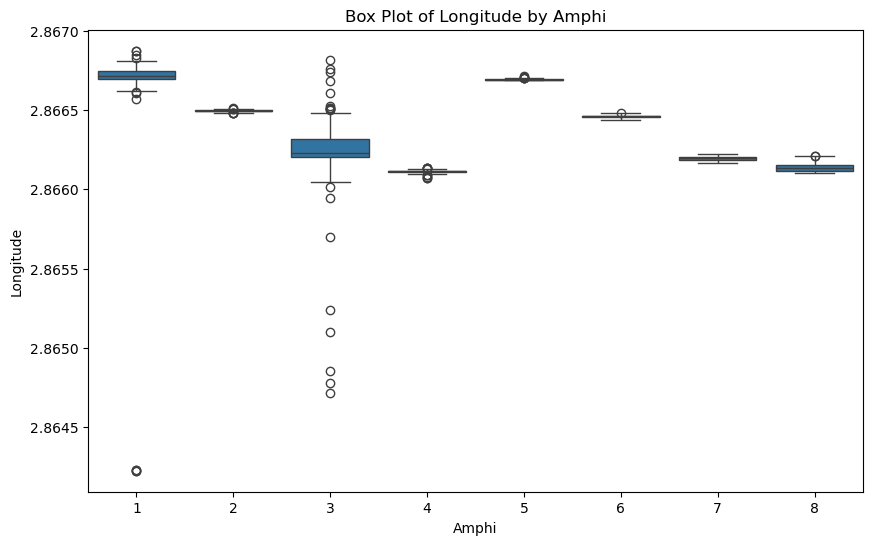

In [17]:
plt.figure(figsize=(10, 6))
sns.boxplot(x='Amphi', y='Longitude', data=df)
plt.title('Box Plot of Longitude by Amphi')
plt.xlabel('Amphi')
plt.ylabel('Longitude')
plt.show()

The boxplot shows longitude distribution for each amphitheater. Amphitheaters are clearly separated by longitude, with each amphi occupying a distinct range. Floor 1 amphitheaters (1-4) have lower longitude values (~-7.9) while floor 2 amphitheaters (5-8) have higher values (~-7.88). This clear separation makes longitude a strong predictor for amphitheater identification.

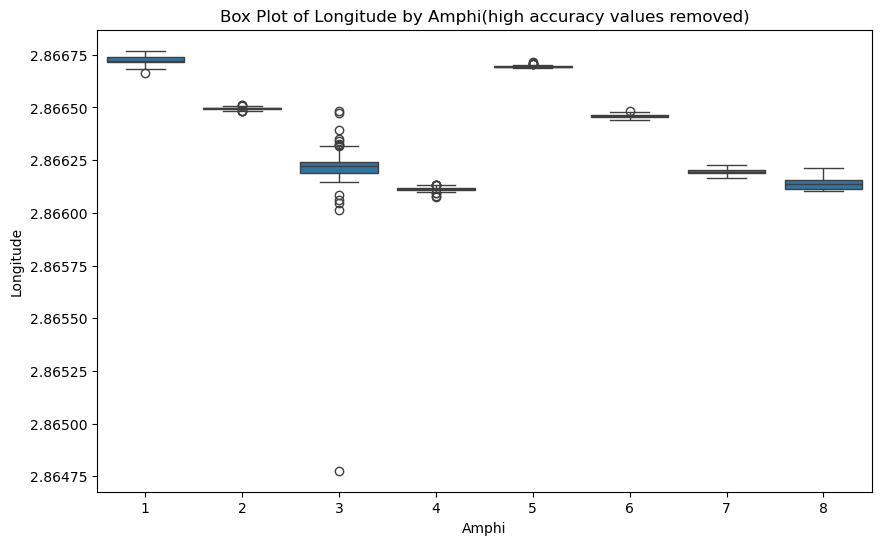

In [18]:
plt.figure(figsize=(10, 6))
sns.boxplot(x='Amphi', y='Longitude', data=normal_accuracy)
plt.title('Box Plot of Longitude by Amphi(high accuracy values removed)')
plt.xlabel('Amphi')
plt.ylabel('Longitude')
plt.show()

After filtering out high accuracy points (>25m), the longitude distribution becomes tighter with reduced variance. The separation between amphitheaters remains clear, but the data points are more concentrated within their respective ranges. This filtering improves the reliability of longitude as a feature for classification.

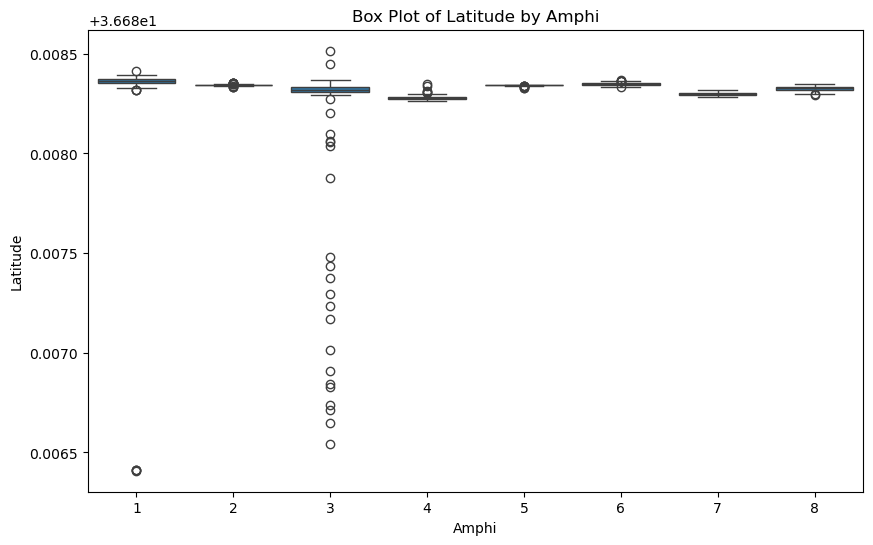

In [19]:
plt.figure(figsize=(10, 6))
sns.boxplot(x='Amphi', y='Latitude', data=df)
plt.title('Box Plot of Latitude by Amphi')
plt.xlabel('Amphi')
plt.ylabel('Latitude')
plt.show()

The boxplot shows latitude distribution for each amphitheater. Unlike longitude, latitude shows significant overlap between amphitheaters, making it a weaker feature for distinguishing between them. The latitude ranges for most amphitheaters fall within a narrow band, indicating that latitude alone may not be sufficient for accurate classification.

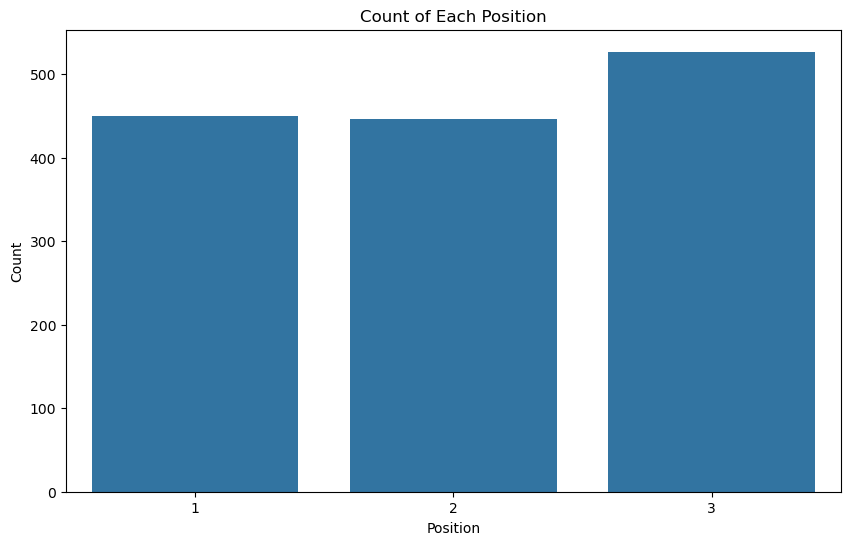

In [20]:
df_p = df.groupby(['Position']).size().reset_index(name='Count')
plt.figure(figsize=(10, 6))
sns.barplot(x='Position', y='Count', data=df_p)
plt.title('Count of Each Position')
plt.xlabel('Position')
plt.ylabel('Count')
plt.show()

positions are roughly balanced overall, position 3(back) has slightly more samples, this is acceptable and should not cause major class imbalance issues for position prediction

In [21]:
df_position = df.groupby(['Amphi', 'Position']).size().reset_index(name='Count')
print(df_position)

    Amphi  Position  Count
0       1         1     42
1       1         2     45
2       1         3     64
3       2         1     62
4       2         2     52
5       2         3     70
6       3         1     60
7       3         2     48
8       3         3     67
9       4         1     48
10      4         2     45
11      4         3     79
12      5         1     36
13      5         2     33
14      5         3     35
15      6         1     50
16      6         2     69
17      6         3     42
18      7         1     79
19      7         2     82
20      7         3     94
21      8         1     73
22      8         2     73
23      8         3     76


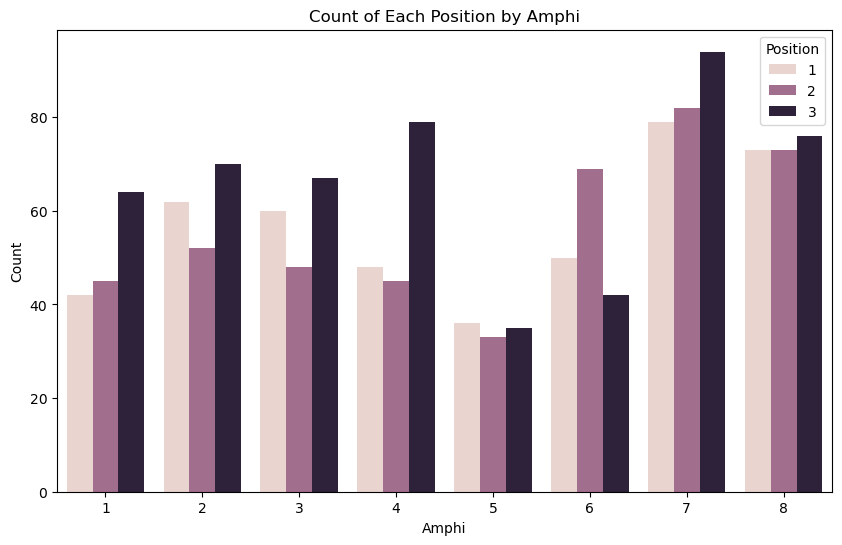

In [22]:
plt.figure(figsize=(10, 6))
sns.barplot(x='Amphi', y='Count', hue='Position', data=df_position)
plt.title('Count of Each Position by Amphi')
plt.xlabel('Amphi')
plt.ylabel('Count')
plt.legend(title='Position')
plt.show()

The bar plot shows the count of each position (front, middle, back) for each amphitheater. Most amphitheaters have a relatively balanced distribution across positions, with slight variations. Amphitheater 5 has notably fewer samples overall, which could lead to poor prediction performance for that amphitheater. The balanced distribution in other amphitheaters suggests that position classification should not suffer from major class imbalance issues.

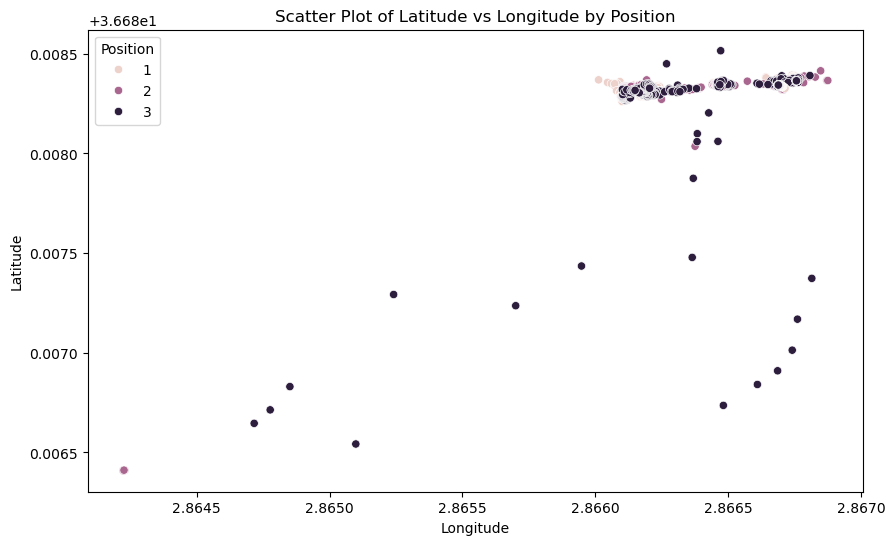

In [23]:
plt.figure(figsize=(10, 6))
sns.scatterplot(x='Longitude', y='Latitude', hue='Position', data=df)
plt.title('Scatter Plot of Latitude vs Longitude by Position')
plt.xlabel('Longitude')
plt.ylabel('Latitude')
plt.legend(title='Position')
plt.show()

The scatter plot shows the distribution of positions (front, middle, back) across all GPS coordinates. The three positions are heavily overlapping in both latitude and longitude, indicating that GPS coordinates alone may not be sufficient to distinguish between positions within an amphitheater. This suggests that position prediction will be more challenging than amphitheater prediction.

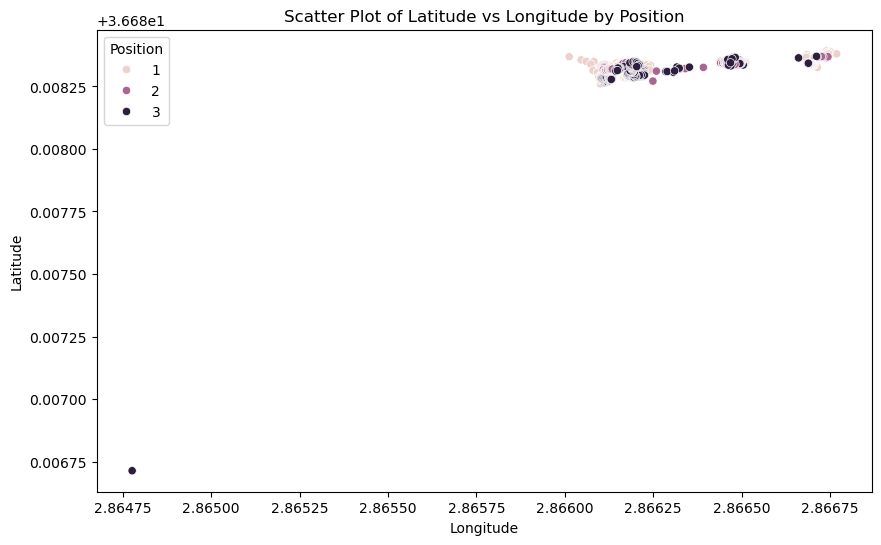

In [24]:
plt.figure(figsize=(10, 6))
sns.scatterplot(x='Longitude', y='Latitude', hue='Position', data=normal_accuracy)
plt.title('Scatter Plot of Latitude vs Longitude by Position')
plt.xlabel('Longitude')
plt.ylabel('Latitude')
plt.legend(title='Position')
plt.show()

After filtering out high accuracy points (>25m), the scatter plot still shows significant overlap between positions. The positions remain indistinguishable based on GPS coordinates alone, even with the filtered data. This reinforces the finding that position prediction will require additional features or more sophisticated modeling techniques.

position distribution is roughly balanced across most amphitheaters, however amphi 5 has very few samples overall compared to others, this confirms the class imbalance issue noted earlier, for the rest the distribution between front middle and back is acceptable

In [25]:
# position vs altitude in each amphetheater
df_amphi = df.groupby(['Amphi', 'Position']).agg(
    {
        'Altitude_m': ['mean', 'median', 'std'],
    }
)
df_amphi

Altitude_m                 
                      mean median       std
Amphi Position                             
1     1         180.116667  181.3  2.358163
      2         180.555556  181.3  2.162443
      3         179.878125  181.4  2.356111
2     1         177.066129  177.1  0.213437
      2         177.100000  177.1  0.235147
      3         177.081429  177.1  0.188274
3     1         179.770000  181.2  2.139008
      2         179.456250  181.2  2.109846
      3         179.308955  181.2  2.083174
4     1         176.475000  176.4  0.104168
      2         176.480000  176.4  0.112006
      3         176.544304  176.5  0.128848
5     1         181.516667  181.5  0.037796
      2         181.539394  181.5  0.049620
      3         181.522857  181.5  0.042604
6     1         181.116000  181.1  0.201383
      2         181.178261  181.1  0.228080
      3         181.104762  181.1  0.214080
7     1         181.343038  181.3  0.109408
      2         181.407317  181.5  0.100346
      3         181.344681  181.3  0.083752
8     1         177.438356  176.8  1.847643
      2         177.347945  176.8  1.767540
      3         178.144737  176.8  2.240797

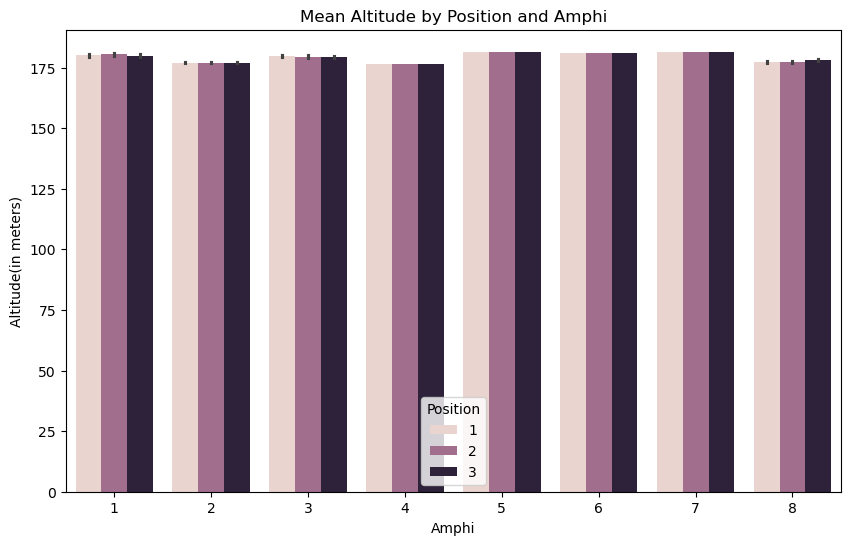

In [26]:
# visualize the mean altitude for each position in each amphetheater
plt.figure(figsize=(10, 6))
sns.barplot(x='Amphi', y='Altitude_m', hue='Position', data=df)
plt.title('Mean Altitude by Position and Amphi')
plt.xlabel('Amphi')
plt.ylabel('Altitude(in meters)')
plt.legend(title='Position')
plt.show()

altitude mean and std vary significantly between amphitheaters, amphitheaters 2,4,5,6,7 have very low std (less than 0.25m) which means altitude is very stable and reliable in these amphitheaters, on the other hand amphitheaters 1,3 and 8 have high std (around 2m) which is consistent with their poor gps accuracy noted before
regarding floors, floor 1 amphitheaters(1-4) have mean altitude around [176-180]m while floor 2 amphitheaters(5-8) are around [181]m, this confirms that altitude is a strong feature to distinguish between floors
however within the same amphitheater, altitude does not change significantly across positions(front,middle,back), the differences are less than 1m in most cases, so altitude alone will not help predict the position inside the amphitheater

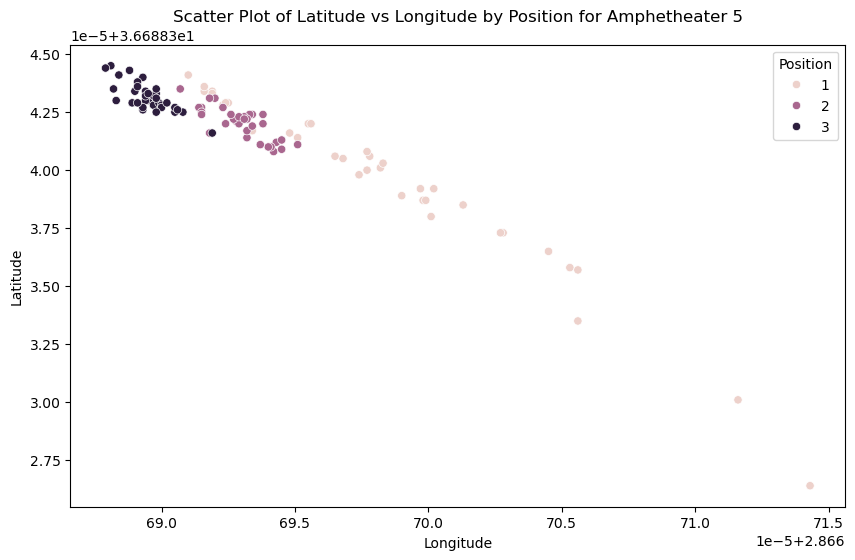

In [27]:
# take example of amphetheater 5 to check how longitude and latitude  are distributed in it
df_amphi_5 = df[df['Amphi'] == 5]
plt.figure(figsize=(10, 6))
sns.scatterplot(x='Longitude', y='Latitude', hue='Position', data=df_amphi_5)
plt.title('Scatter Plot of Latitude vs Longitude by Position for Amphetheater 5')
plt.xlabel('Longitude')
plt.ylabel('Latitude')
plt.legend(title='Position')
plt.show()

it looks that inside amphitheater,  Longitude and Latitude are better separated between positions compared to altitude

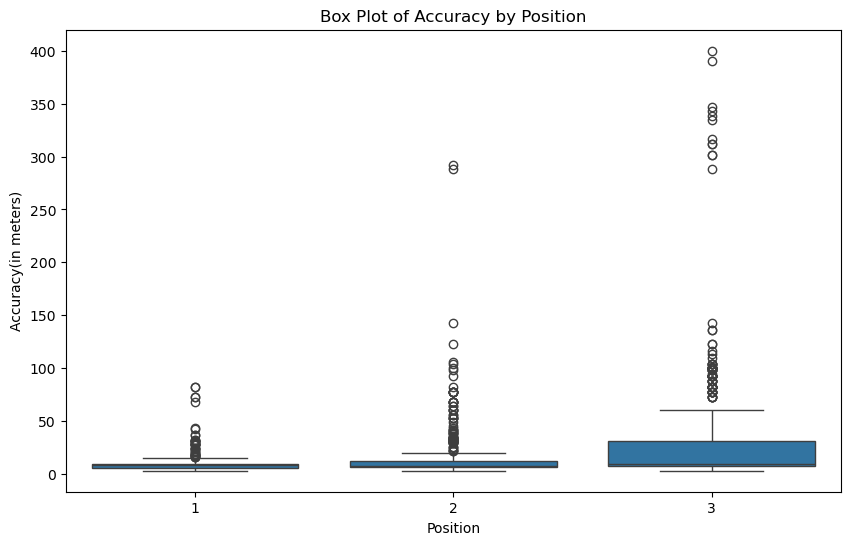

In [28]:
plt.figure(figsize=(10, 6))
sns.boxplot(x='Position', y='Accuracy_m', data=df)
plt.title('Box Plot of Accuracy by Position')
plt.xlabel('Position')
plt.ylabel('Accuracy(in meters)')
plt.show()

The boxplot shows GPS accuracy distribution for each position (front, middle, back). All three positions have similar accuracy distributions, with medians around 5-10 meters and similar spread. This indicates that GPS signal quality is consistent across all positions, so accuracy is unlikely to be a distinguishing feature for position prediction.

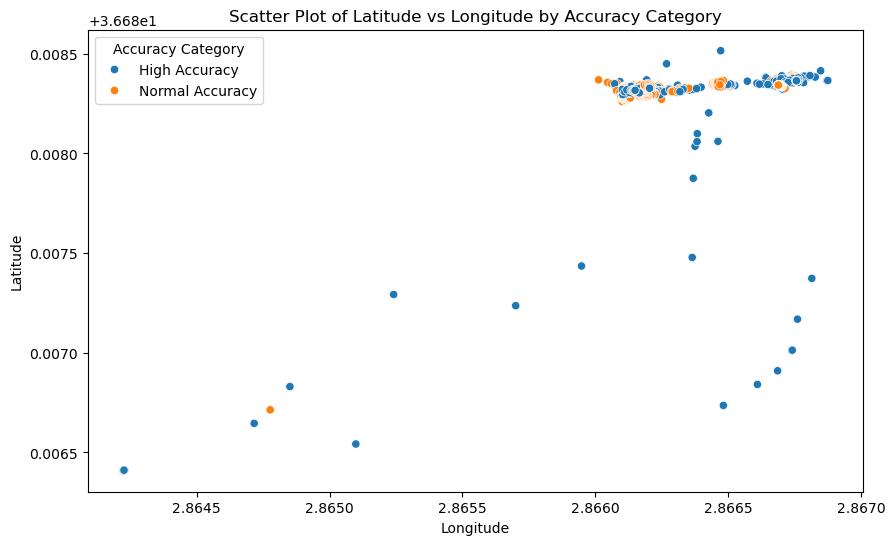

In [29]:
# high accuracy vs normal accuracy for each position
df_copy = df.copy()
df_copy['Accuracy_Category'] = df_copy['Accuracy_m'].apply(lambda x: 'High Accuracy' if x > 25 else 'Normal Accuracy')
# compare varince of longitude and latitude for high accuracy and normal accuracy
plt.figure(figsize=(10, 6))
sns.scatterplot(x='Longitude', y='Latitude', hue='Accuracy_Category', data=df_copy)
plt.title('Scatter Plot of Latitude vs Longitude by Accuracy Category')
plt.xlabel('Longitude')
plt.ylabel('Latitude')
plt.legend(title='Accuracy Category')
plt.show()


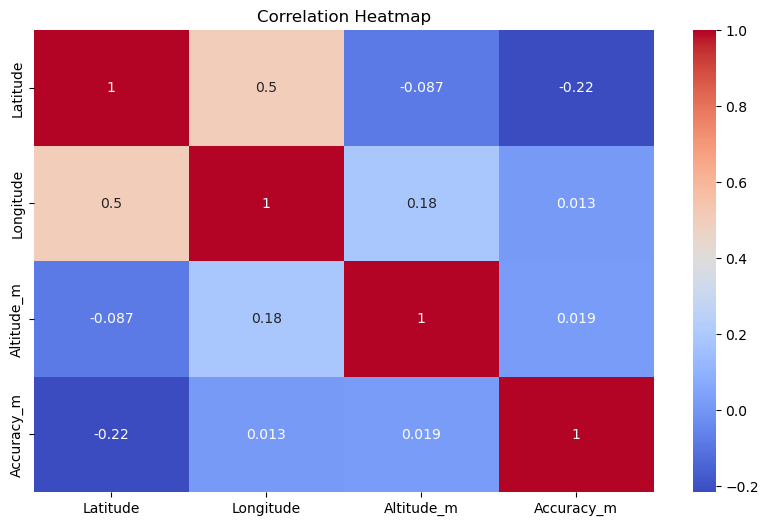

In [30]:
plt.figure(figsize=(10, 6))
sns.heatmap(df[['Latitude','Longitude','Altitude_m','Accuracy_m']].corr(), annot=True, cmap='coolwarm')
plt.title('Correlation Heatmap')
plt.show()


features are not stongly correlated with each other, this means that each feature provides unique information that can be useful for classification, and there is no redundancy between features.

from above analysis we can conclude that:
- Altitude is a strong feature for distinguishing between floors, but not for predicting position within an amphitheater.
- Longitude is a strong feature for distinguishing between amphitheaters, while latitude is less useful due to significant overlap.
- Longitude and Altitude can be useful to predict position inside amphitheater, but they are not sufficient alone, we may need to engineer new features or use more sophisticated models to achieve good position prediction performance.
- amphitheater 5 has very few samples overall compared to others, this confirms the class imbalance issue noted earlier, for the rest the distribution between front middle and back is acceptable, so we may consider stratified sampling to handle this issue when building our model.
- high accuracy points (>25m) are likely to be noisy data, especially amphitheaters 1,3 and 8, we may consider removing extreme values(>100m).


In [31]:
# remove high accuracy points and check correlation again
df_clean = df[df['Accuracy_m'] <= 100]
print("number of points after removing high accuracy points: ", len(df_clean))
print("number of points removed: ", len(df) - len(df_clean))

number of points after removing high accuracy points:  1391
number of points removed:  33


In [32]:
df['Amphi'].value_counts()

Amphi
7    255
8    222
2    184
3    175
4    172
6    161
1    151
5    104
Name: count, dtype: int64

In [33]:
# add new feature which is the distance from the center of the amphitheater, we will use the mean longitude and latitude for each amphitheater as the center
def calculate_centoids(X, y):  
    X = X.copy()
    y = y.copy()
    X['Amphi'] = y  
    X = X.groupby('Amphi').agg({'Longitude': 'mean', 'Latitude': 'mean'}).reset_index()
    X.columns = ['Amphi', 'Center_Longitude', 'Center_Latitude']
    X.drop(columns=['Amphi'], inplace=True)
    return X


In [34]:
def distance_to_centroids(X, Y):
    """
        X: dataset with longitude and latitude
        Y: dataset with center longitude and latitude for each amphitheater
    """
    # calculate distance from each point to the center of the amphitheater
    for row in Y.itertuples():
            X[f'Distance_to_Centroid_{row.Index}'] = np.sqrt((X['Longitude'] - row.Center_Longitude) ** 2 + (X['Latitude'] - row.Center_Latitude) ** 2)
    return X
    

In [35]:
from sklearn.model_selection import train_test_split
X = df_clean.drop(columns=['Amphi', 'Position'])
y = df_clean['Amphi']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

In [36]:
X_centroids = calculate_centoids(X_train,y_train)
X_train = distance_to_centroids(X_train, X_centroids)
X_test = distance_to_centroids(X_test, X_centroids)


In [37]:
X_centroids.to_csv('X_train_centroids.csv', index=False)

In [38]:
# since dataset is relatively small, we will use crossvalidation to evaluate our model
from sklearn.model_selection import cross_val_score
def evaluate_model(model, X, y):
    measures = ['accuracy', 'precision_macro', 'recall_macro', 'f1_macro']
    scores = {}
    for measure in measures:
        scores[measure] = cross_val_score(model, X, y, cv=5, scoring=measure).mean()
    return scores

In [39]:
# if linear model used we will need specific pipeline contains scaling and log transform for accurracy
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler, FunctionTransformer
from sklearn.impute import SimpleImputer
from sklearn.compose import ColumnTransformer

num_pipeline = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])
accuracy_pipeline = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')),
    ('log_transform', FunctionTransformer(np.log1p)),
    ('scaler', StandardScaler())
])

preprocessor = ColumnTransformer(transformers=[
    ('num', num_pipeline, ['Longitude', 'Latitude', 'Altitude_m']),
    ('accuracy', accuracy_pipeline, ['Accuracy_m'])
])

In [40]:
# example how to use it
from sklearn.linear_model import LogisticRegression
log = LogisticRegression(random_state=42)
pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', log)
])
scores = evaluate_model(pipeline, X_train, y_train)

In [41]:
print("Model Evaluation Scores:")
for measure, score in scores.items():
    print(f"{measure.capitalize()}: {score:.4f}")

Model Evaluation Scores:
Accuracy: 0.8894
Precision_macro: 0.9002
Recall_macro: 0.8906
F1_macro: 0.8904


In [42]:
pipeline.fit(X_train, y_train)

,steps,"[('preprocessor', ...), ('classifier', ...)]"
,transform_input,None
,memory,None
,verbose,False
,transformers,"[('num', ...), ('accuracy', ...)]"
,remainder,'drop'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True


In [43]:
from sklearn.metrics import classification_report, confusion_matrix
y_pred = pipeline.predict(X_test)
print("Classification Report:")
print(classification_report(y_test, y_pred))
print("Confusion Matrix:")
print(confusion_matrix(y_test, y_pred))

Classification Report:
              precision    recall  f1-score   support

           1       0.92      0.89      0.91        27
           2       0.95      1.00      0.97        37
           3       0.91      0.62      0.74        34
           4       0.94      0.88      0.91        34
           5       0.95      0.90      0.93        21
           6       1.00      1.00      1.00        32
           7       0.86      1.00      0.93        51
           8       0.75      0.84      0.79        43

    accuracy                           0.90       279
   macro avg       0.91      0.89      0.90       279
weighted avg       0.90      0.90      0.89       279

Confusion Matrix:
[[24  2  0  0  1  0  0  0]
 [ 0 37  0  0  0  0  0  0]
 [ 0  0 21  1  0  0  4  8]
 [ 0  0  0 30  0  0  0  4]
 [ 2  0  0  0 19  0  0  0]
 [ 0  0  0  0  0 32  0  0]
 [ 0  0  0  0  0  0 51  0]
 [ 0  0  2  1  0  0  4 36]]


In [44]:
new_instance = pd.read_csv('new_instance.csv')
new_instance = new_instance.drop(columns=['Amphi', 'Position', 'Timestamp', 'Type'], axis=1)
new_instance = distance_to_centroids(new_instance, X_centroids)
new_instance_prediction = pipeline.predict(new_instance)
print("Predicted Amphi for the new instance: ", new_instance_prediction[0])

Predicted Amphi for the new instance:  1


In [45]:
# for tree based models scaling and log transform are not needed, so we will use different pipeline for them
from sklearn.ensemble import RandomForestClassifier
rf = RandomForestClassifier(random_state=42)
pipeline_rf = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')),
    ('classifier', rf)
])
scores_rf = evaluate_model(pipeline_rf, X_train, y_train)
print("Model Evaluation Scores:")
for measure, score in scores.items():
    print(f"{measure.capitalize()}: {score:.4f}")



Model Evaluation Scores:
Accuracy: 0.8894
Precision_macro: 0.9002
Recall_macro: 0.8906
F1_macro: 0.8904


In [46]:
pipeline_rf.fit(X_train, y_train)

,steps,"[('imputer', ...), ('classifier', ...)]"
,transform_input,None
,memory,None
,verbose,False
,missing_values,nan
,strategy,'median'
,fill_value,None
,copy,True
,add_indicator,False
,keep_empty_features,False
,n_estimators,100


In [53]:
# ...existing code...
importances = pipeline_rf.named_steps['classifier'].feature_importances_
feature_names = X_train.columns  # Use original column names
importance_df = pd.DataFrame({
    'feature': feature_names,
    'importance': importances
}).sort_values('importance', ascending=False)
print(importance_df)

                   feature  importance
7   Distance_to_Centroid_3    0.140954
6   Distance_to_Centroid_2    0.119379
10  Distance_to_Centroid_6    0.096165
5   Distance_to_Centroid_1    0.094626
8   Distance_to_Centroid_4    0.088431
9   Distance_to_Centroid_5    0.086293
11  Distance_to_Centroid_7    0.078173
4   Distance_to_Centroid_0    0.077069
1                Longitude    0.069435
2               Accuracy_m    0.059232
3               Altitude_m    0.056955
0                 Latitude    0.033286


In [47]:
y_pred = pipeline_rf.predict(X_test)
print("Classification Report:")
print(classification_report(y_test, y_pred))
print("Confusion Matrix:")
print(confusion_matrix(y_test, y_pred))

Classification Report:
              precision    recall  f1-score   support

           1       0.96      1.00      0.98        27
           2       0.95      0.97      0.96        37
           3       0.94      0.88      0.91        34
           4       1.00      1.00      1.00        34
           5       1.00      0.95      0.98        21
           6       1.00      1.00      1.00        32
           7       1.00      1.00      1.00        51
           8       0.95      0.98      0.97        43

    accuracy                           0.97       279
   macro avg       0.98      0.97      0.97       279
weighted avg       0.97      0.97      0.97       279

Confusion Matrix:
[[27  0  0  0  0  0  0  0]
 [ 0 36  1  0  0  0  0  0]
 [ 0  2 30  0  0  0  0  2]
 [ 0  0  0 34  0  0  0  0]
 [ 1  0  0  0 20  0  0  0]
 [ 0  0  0  0  0 32  0  0]
 [ 0  0  0  0  0  0 51  0]
 [ 0  0  1  0  0  0  0 42]]


In [48]:
new_instance_prediction = pipeline_rf.predict(new_instance)
print("Predicted Amphi for the new instance: ", new_instance_prediction[0])

Predicted Amphi for the new instance:  3


# note: new instance is new point from amphi 3, randomforst correctly find it but logistic regression fails